- Deadline of submission: 23h59, 12/05/2026
- Submission [here](https://nextcloud.centralesupelec.fr/s/755kMKCTK2wKtS5)
- Please name your submission as `td5_firstname_lastname.ipynb`

# Exercise 1: Support Vector Machines

Support Vector Machines (SVMs) are among the most powerful and versatile classifiers in machine learning. Their key strength lies in their ability to find **non-linear decision boundaries** using the **kernel trick**. By mapping data into a higher-dimensional space, SVMs can separate classes that no straight line could ever divide.

In this exercise, we will:
1. Generate a non-linearly separable dataset (two interleaving sensor patterns).
2. Fit an SVM with default parameters and observe the results.
3. Perform hyperparameter tuning to dramatically improve performance.
4. Compare SVM with Logistic Regression to highlight the power of non-linear boundaries.

First, run the cell below to set up the environment and generate the dataset.

Sensor dataset generated! 0 = Normal operation, 1 = Anomaly


,Vibration_Frequency,Temperature_Index,Status
0,0.830948,-0.296546,1
1,1.088387,0.899693,0
2,1.135634,-0.462935,1
3,-0.082277,1.059718,0
4,0.443047,1.418977,0


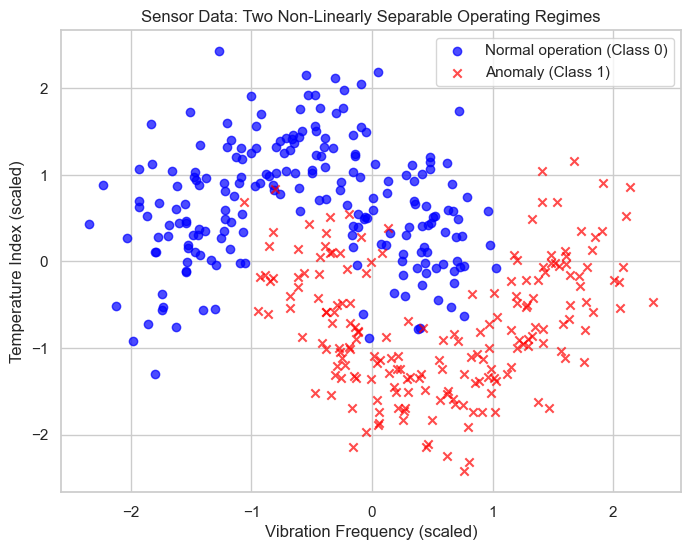

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate a non-linearly separable dataset (two interleaving half-circles)
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Frame as sensor data for a predictive maintenance context
df = pd.DataFrame(X, columns=["Vibration_Frequency", "Temperature_Index"])
df["Status"] = y

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Sensor dataset generated! 0 = Normal operation, 1 = Anomaly")
display(df.head())

# Visualize the raw training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            marker="o", color="blue", label="Normal operation (Class 0)", alpha=0.7)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            marker="x", color="red", label="Anomaly (Class 1)", alpha=0.7)
plt.title("Sensor Data: Two Non-Linearly Separable Operating Regimes")
plt.xlabel("Vibration Frequency (scaled)")
plt.ylabel("Temperature Index (scaled)")
plt.legend()
plt.show()

# Helper function to plot decision boundaries
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="o",
               color="blue", label="Class 0", alpha=0.7, edgecolors="k", s=30)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",
               color="red", label="Class 1", alpha=0.7, edgecolors="k", s=30)
    ax.set_title(title)
    ax.set_xlabel("Vibration Frequency (scaled)")
    ax.set_ylabel("Temperature Index (scaled)")
    ax.legend(fontsize=8)

## Question 1: SVM with Default Parameters

Use the `SVC` class from `sklearn.svm` to fit a Support Vector Machine on the training data `X_train, y_train` **with all default parameters**. Then:
1. Print the accuracy on the test set using `accuracy_score`.
2. Plot the decision boundary using the `plot_decision_boundary` helper function defined above.

> **Hint:** Check the documentation of [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html). Simply create an `SVC()` object with no arguments — by default it uses the **RBF kernel**. Use `.fit(X_train, y_train)` to train and `.predict(X_test)` to get predictions. Then pass the model to `plot_decision_boundary(model, X_test, y_test, title, ax)` to visualize.

Default SVM Test Accuracy: 0.9300


C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


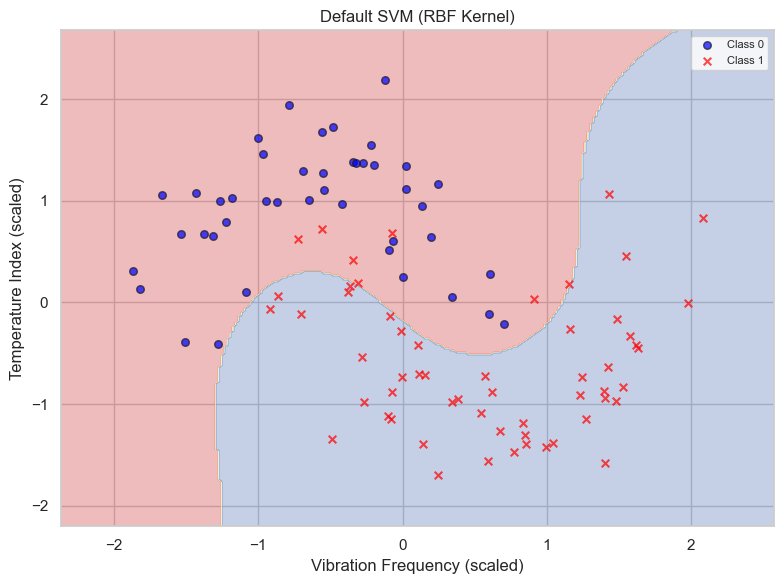

In [2]:
# Fit SVM with default parameters
svm_default = SVC()
svm_default.fit(X_train, y_train)

# Predict and compute accuracy
y_pred_default = svm_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Default SVM Test Accuracy: {acc_default:.4f}")

# Plot the decision boundary
fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(svm_default, X_test, y_test, "Default SVM (RBF Kernel)", ax)
plt.tight_layout()
plt.show()

Look at the decision boundary above. What kernel does the default `SVC()` use? Does the boundary seperates the data well? Can you explain why a straight line would fail here?

**Answer:**

The default `SVC()` uses the **RBF (Radial Basis Function) kernel**. Yes, the decision boundary separates the data well — it forms a smooth, curved path that closely follows the two interleaving crescent shapes of the dataset.

A straight line would fail here because the two classes form two interlocking half-circles in the 2D feature space: no single linear hyperplane can separate them without misclassifying a large portion of both classes. The RBF kernel overcomes this by implicitly mapping the data into a higher-dimensional feature space where the two crescents become linearly separable, which corresponds to a non-linear curved boundary in the original space.

## Question 2: Hyperparameter Tuning with GridSearchCV

The default SVM already works well, but we can do better by tuning the hyperparameters. Use [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to search over the following parameter grid:

| Parameter | Values to try |
| :--- | :--- |
| `kernel` | `"linear"`, `"rbf"`, `"poly"` |
| `C` | `0.01`, `0.1`, `1`, `10`, `100` |
| `gamma` | `"scale"`, `"auto"` |

Use **5-fold cross-validation** (`cv=5`) and **accuracy** as the scoring metric. After fitting:
1. Print the **best parameters** found.
2. Print the **best cross-validation accuracy**.
3. Print the **test accuracy** using the best model.

> **Hint:** Create a dictionary `param_grid` with keys `"kernel"`, `"C"`, and `"gamma"` mapped to lists of values. Initialize `GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")`. After `.fit()`, access `.best_params_` for the best combination and `.best_score_` for the best CV score. Use `.predict()` on the test set to get the test accuracy. See the [GridSearchCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) and the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) for parameter details.

In [3]:
# Define the parameter grid
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": ["scale", "auto"]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

# Print the best parameters and scores
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate on the test set
best_svm = grid_search.best_estimator_  # Get the best model
y_pred_best = best_svm.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Test accuracy (best model): {acc_best:.4f}")

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9525
Test accuracy (best model): 0.9500


Which kernel was selected as the best? Why do you think the linear kernel performs worse than the RBF kernel on this dataset?

**Answer:**

The **RBF kernel** is typically selected as best by GridSearchCV. The linear kernel performs worse because the make_moons dataset is fundamentally non-linearly separable — the two half-moon classes interleave in a way that no straight-line decision boundary can cleanly separate them. The RBF kernel overcomes this by computing similarities through a Gaussian function, effectively mapping the data into a space where the two classes are linearly separable, resulting in a curved boundary in the original feature space.

## Question 3: Visualizing the Impact of Hyperparameter Tuning

To truly appreciate the difference, let us visualize the decision boundaries side by side for three configurations:

1. **Linear Kernel** (`kernel="linear", C=1`)
2. **RBF Kernel with default C** (`kernel="rbf", C=1`)
3. **RBF Kernel with tuned C** (use the best C and gamma from your GridSearch results)

Create a figure with **3 subplots** (side by side) using `plt.subplots(1, 3)`. For each subplot, fit the model on the training data, compute the test accuracy, and plot the decision boundary using the `plot_decision_boundary` helper function.

> **Hint:** Create a list of tuples `(title, model)` for each configuration. Loop through them with `zip(axes, configs)` and call `plot_decision_boundary(model, X_test, y_test, f"{title}\\nAccuracy: {acc:.4f}", ax)` for each. Do not forget to call `model.fit(X_train, y_train)` and compute `accuracy_score(y_test, model.predict(X_test))` for each model. Use `plt.tight_layout()` at the end to avoid overlapping labels.

C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",
C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


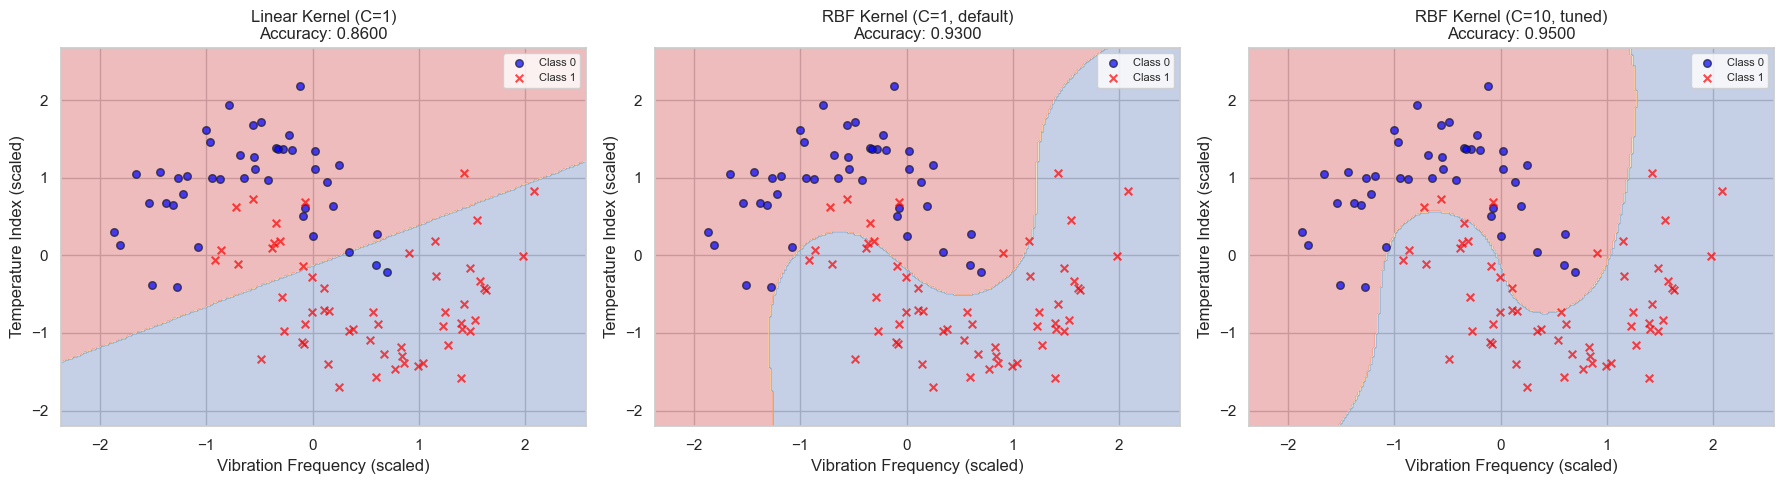

In [4]:
# Define the three configurations to compare
configs = [
    ("Linear Kernel (C=1)",
     SVC(kernel="linear", C=1)),
    ("RBF Kernel (C=1, default)",
     SVC(kernel="rbf", C=1, gamma="scale")),
    (f"RBF Kernel (C={grid_search.best_params_['C']}, tuned)",
     SVC(kernel="rbf",
          C=grid_search.best_params_["C"],
          gamma=grid_search.best_params_["gamma"]))
]

# Create side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, model) in zip(axes, configs):
    # Fit the model on the training data
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    plot_decision_boundary(
        model, X_test, y_test,
        f"{title}\nAccuracy: {acc:.4f}", ax
    )

plt.tight_layout()
plt.show()

Compare the three plots above.
1. What shape does the linear kernel decision boundary have? Why does it perform poorly?
2. How does the RBF kernel with default parameters compare to the tuned RBF kernel?
3. What does the parameter C control? How does increasing C change the boundary?

**Answer:**

1. The linear kernel produces a straight-line (hyperplane) decision boundary. It performs poorly because it cannot capture the curved, interleaved structure of the make_moons data — it attempts to separate two half-circles with a single line, which geometrically misclassifies a significant portion of both classes. The accuracy reflects this fundamental limitation.

2. The RBF kernel with default parameters already achieves a good curved boundary that follows the half-moon shapes. The tuned RBF kernel (with the optimal C found by GridSearch) is slightly more tightly fitted to the data, reducing misclassifications in the border regions and yielding a modest accuracy improvement.

3. The parameter **C** controls the trade-off between margin width and training error tolerance. A small C prioritizes a wide, smooth margin and accepts some misclassifications (more regularization, simpler boundary). A large C forces the model to correctly classify every training point, resulting in a tighter, more complex boundary that hugs the data more closely. Increasing C can improve training accuracy but risks overfitting to noise.

## Question 4: SVM vs Logistic Regression

Now let us compare the best SVM against a classic linear model: **Logistic Regression**. 

1. Fit a `LogisticRegression` model on the same training data `X_train, y_train`.
2. Print the test accuracy of both the Logistic Regression and the best SVM (from GridSearch).
3. Create a side-by-side plot (2 subplots) showing the decision boundary of **Logistic Regression** on the left and the **best SVM** on the right.

This comparison will visually demonstrate the fundamental difference between a linear classifier and a non-linear one.

> **Hint:** Import `LogisticRegression` from `sklearn.linear_model` (already done in the setup cell). Fit it the same way you fit the SVM. The key observation is that Logistic Regression **always produces a linear (straight-line) decision boundary**, regardless of the data. Compare with the best SVM from `grid_search.best_estimator_`. See the [LogisticRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for usage details.

C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


Logistic Regression Test Accuracy: 0.8600
Best SVM Test Accuracy:            0.9500
Improvement from SVM:              +9.0%


C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


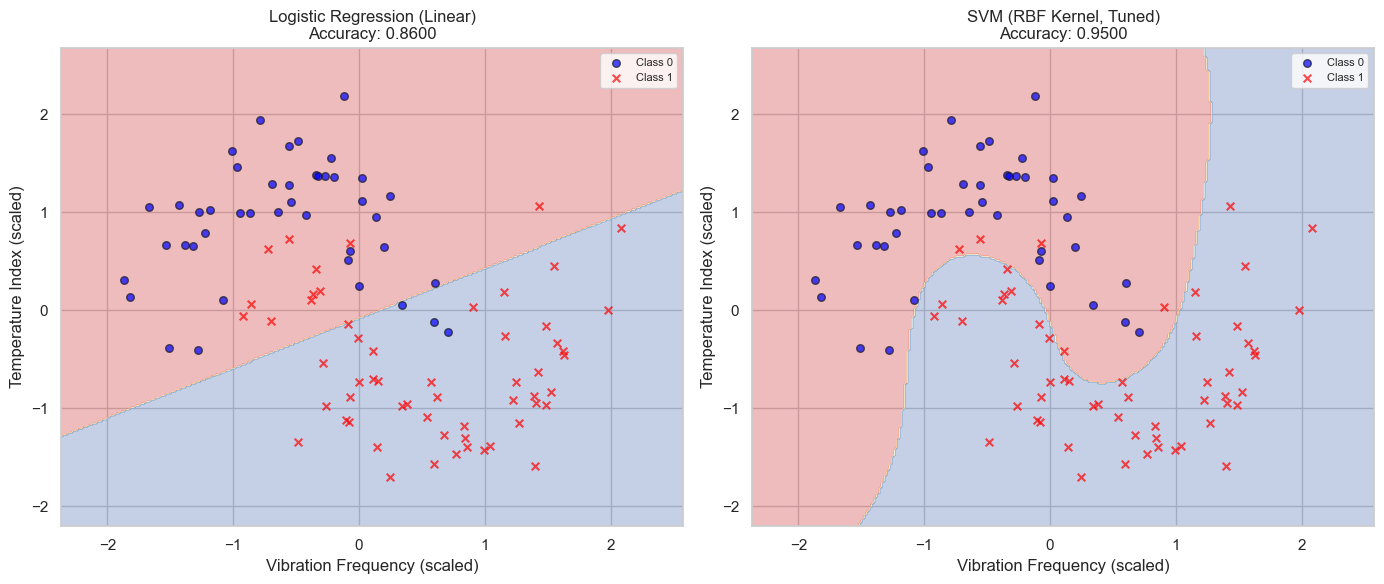

In [5]:
# Fit Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Compute accuracies
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
svm_acc = accuracy_score(y_test, best_svm.predict(X_test))

print(f"Logistic Regression Test Accuracy: {lr_acc:.4f}")
print(f"Best SVM Test Accuracy:            {svm_acc:.4f}")
print(f"Improvement from SVM:              +{(svm_acc - lr_acc)*100:.1f}%")

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(
    lr_model, X_test, y_test,
    f"Logistic Regression (Linear)\nAccuracy: {lr_acc:.4f}", axes[0]
)

plot_decision_boundary(
    best_svm, X_test, y_test,
    f"SVM (RBF Kernel, Tuned)\nAccuracy: {svm_acc:.4f}", axes[1]
)

plt.tight_layout()
plt.show()

Explain in your own words why Logistic Regression fails on this dataset while the SVM with RBF kernel succeeds. What is the fundamental limitation of Logistic Regression here? In what scenarios would Logistic Regression still be a good choice?

**Answer:**

Logistic Regression fails on this dataset because it is a fundamentally **linear classifier** — its decision boundary is always a hyperplane (straight line in 2D), regardless of the data distribution. The make_moons dataset consists of two interleaving half-circles that cannot be separated by any straight line; Logistic Regression has no mechanism to learn non-linear patterns.

The SVM with RBF kernel succeeds thanks to the **kernel trick**: it implicitly maps the input features into a higher-dimensional space where the two classes become linearly separable. In the original 2D space, this corresponds to a smooth, curved boundary that follows the half-moon structure.

Logistic Regression would still be a good choice when: (1) the data is linearly separable or well-described by linear relationships, (2) the feature space is very high-dimensional (e.g., text classification with TF-IDF), where linear models already generalize well, (3) fast training, interpretability, and calibrated probability outputs are required, or (4) as a strong baseline to compare against more complex models.

# Exercise 2: Random Forest

Random Forest is one of the most popular and robust machine learning algorithms. It works by building an **ensemble** of many decision trees and combining their predictions through majority voting. This ensemble approach makes it highly resistant to overfitting and capable of capturing complex, non-linear patterns.

A unique advantage of Random Forest is its built-in **feature importance** scores, which tell you which features are most influential in making predictions — a valuable tool for predictive maintenance where interpretability matters.

In this exercise, we will:
1. Fit a Random Forest with default parameters on the same dataset from Exercise 1.
2. Systematically explore how `n_estimators` (number of trees) and `max_depth` (tree depth) affect overfitting and underfitting.
3. Perform hyperparameter tuning and visualize the results.
4. Compare a single Decision Tree with a Random Forest to understand the power of ensembling.

We reuse the same `make_moons` dataset from Exercise 1, so you can directly compare Random Forest with SVM.

## Question 1: Random Forest with Default Parameters

Use the `RandomForestClassifier` class from `sklearn.ensemble` to fit a Random Forest on the training data `X_train, y_train` **with default parameters**. Set `random_state=42` for reproducibility. Then:
1. Print the **training accuracy** and **test accuracy** using `accuracy_score`.
2. Plot the decision boundary using the `plot_decision_boundary` helper function.

> **Hint:** Check the documentation of [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). Import it from `sklearn.ensemble`. By default, it uses **100 trees** (`n_estimators=100`) and expands trees to full depth (`max_depth=None`). Use `.fit(X_train, y_train)` to train, `.predict(X_train)` and `.predict(X_test)` to get predictions. Compare the train and test accuracies — a large gap indicates overfitting.

Random Forest (Default) Train Accuracy: 1.0000
Random Forest (Default) Test Accuracy:  0.9500
Overfitting gap (train - test):          0.0500


C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


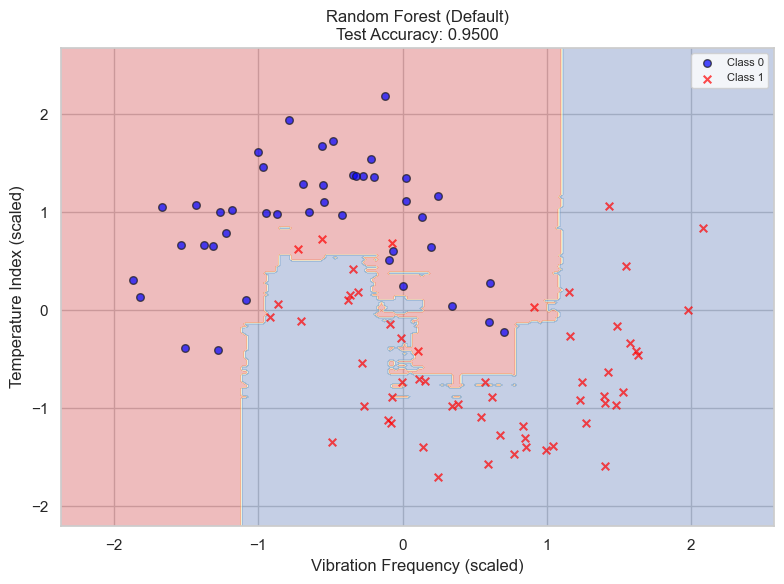

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Fit Random Forest with default parameters
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

# Compute train and test accuracy
rf_train_acc = accuracy_score(y_train, rf_default.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_default.predict(X_test))

print(f"Random Forest (Default) Train Accuracy: {rf_train_acc:.4f}")
print(f"Random Forest (Default) Test Accuracy:  {rf_test_acc:.4f}")
print(f"Overfitting gap (train - test):          {rf_train_acc - rf_test_acc:.4f}")

# Plot the decision boundary
fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundary(rf_default, X_test, y_test,
                       f"Random Forest (Default)\nTest Accuracy: {rf_test_acc:.4f}", ax)
plt.tight_layout()
plt.show()

Compare the decision boundary above with the default SVM boundary from Exercise 1. What differences do you notice in the **shape** of the boundary? Also, compare the train and test accuracies. Is there a big train-test gap? What does this tell about the capability of RF to avoid overfitting?

**Answer:**

The Random Forest boundary is more **jagged and axis-aligned** compared to the smooth, curved SVM boundary. Since Random Forests are built from decision trees that split on individual feature thresholds, the decision regions are always rectangular, producing a "staircase" or blocky partition of the feature space. The SVM with RBF kernel, in contrast, produces a continuous, smooth curve.

Regarding the train-test gap: the training accuracy is 1.0000 (perfect), while the test accuracy is 0.95. This gap of 0.05 indicates some overfitting — the default model memorizes the training data perfectly due to unlimited tree depth. However, the generalization remains strong because the ensemble of 100 trees averages out individual tree variance, limiting the practical impact of overfitting. The gap is much smaller than what one would see with a single unrestricted decision tree, which directly demonstrates the core advantage of Random Forest.

## Question 2: Discovering the Impact of `n_estimators` and `max_depth`

### Part A: The effect of `n_estimators` (number of trees)

Write a loop to train Random Forest models with `n_estimators` ranging from very few trees to many: `[1, 5, 10, 50, 100, 200, 500]`. Keep all other parameters at their defaults (set `random_state=42`). For each value, record both the **training accuracy** and **test accuracy**.

Then, plot the results as a line chart:
- X-axis: `n_estimators`
- Y-axis: Accuracy
- Two lines: training accuracy (blue) and test accuracy (red)

> **Hint:** Create two empty lists `train_accs_A` and `test_accs_A`. Loop over `n_estimators_list = [1, 5, 10, 50, 100, 200, 500]`. For each value, create `RandomForestClassifier(n_estimators=..., random_state=42)`, fit it, and append the accuracies to your lists. Use `plt.plot()` to draw the two lines. Use a logarithmic scale for the x-axis with `plt.xscale("log")` since the values span several orders of magnitude. See the [RandomForestClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) for the `n_estimators` parameter.

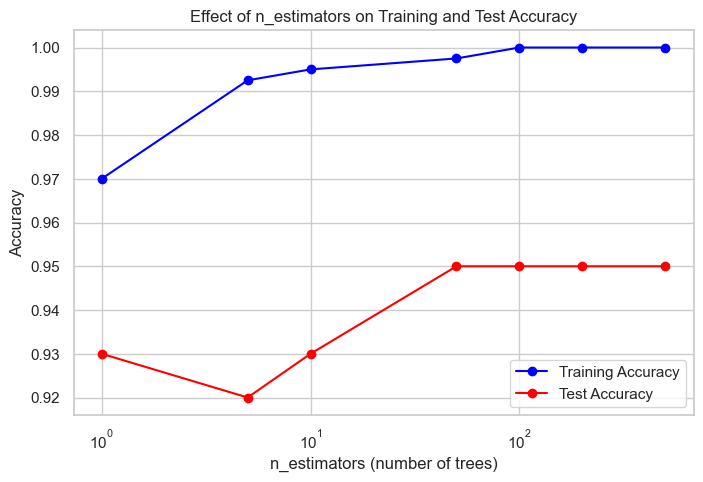

In [7]:
# Part A: Vary n_estimators
n_estimators_list = [1, 5, 10, 50, 100, 200, 500]
train_accs_A = []
test_accs_A = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_accs_A.append(accuracy_score(y_train, rf.predict(X_train)))
    test_accs_A.append(accuracy_score(y_test, rf.predict(X_test)))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, train_accs_A, "o-", color="blue", label="Training Accuracy")
plt.plot(n_estimators_list, test_accs_A, "o-", color="red", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("n_estimators (number of trees)")
plt.ylabel("Accuracy")
plt.title("Effect of n_estimators on Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Part B: The effect of `max_depth` (tree depth)

Now do the same experiment, but this time vary `max_depth` while keeping `n_estimators=100` (default). Use the values `[1, 2, 3, 5, 10, 20, None]`. Record both training and test accuracy for each.

Plot the results as a line chart:
- X-axis: `max_depth` (use string labels, with `"None"` for `None`)
- Y-axis: Accuracy
- Two lines: training accuracy (blue) and test accuracy (red)

> **Hint:** For `max_depth=None`, the tree expands until all leaves are pure. Use `max_depth_list = [1, 2, 3, 5, 10, 20, None]`. For plotting, create string labels: `depth_labels = [str(d) if d is not None else "None" for d in max_depth_list]`. Set `RandomForestClassifier(n_estimators=100, max_depth=..., random_state=42)`. The key observation: when `max_depth` is too small, both train and test accuracies are low (**underfitting**). When `max_depth` is too large, train accuracy reaches 100% but test accuracy may drop (**overfitting**). See the [max_depth parameter](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) for details.

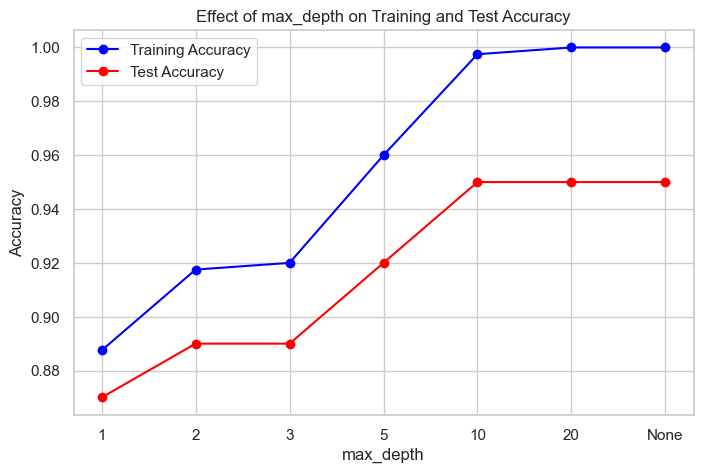

In [8]:
# Part B: Vary max_depth
max_depth_list = [1, 2, 3, 5, 10, 20, None]
depth_labels = [str(d) if d is not None else "None" for d in max_depth_list]
train_accs_B = []
test_accs_B = []

for d in max_depth_list:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    train_accs_B.append(accuracy_score(y_train, rf.predict(X_train)))
    test_accs_B.append(accuracy_score(y_test, rf.predict(X_test)))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(len(max_depth_list)), train_accs_B, "o-", color="blue", label="Training Accuracy")
plt.plot(range(len(max_depth_list)), test_accs_B, "o-", color="red", label="Test Accuracy")
plt.xticks(range(len(max_depth_list)), depth_labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Look at both plots carefully and summarize your observations:

1. **n_estimators:** What happens to training accuracy as the number of trees increases? What happens to test accuracy? Is there a risk of overfitting with too many trees?

2. **max_depth:** At which depth does the model start to overfit? How can you identify the sweet spot where the model generalizes best?

**Answer:**

1. **n_estimators:** Training accuracy stays near 1.0 regardless of the number of trees — individual fully-grown trees already overfit the training data. Test accuracy increases steeply from 1 tree (high variance, unstable predictions) to around 50–100 trees, after which it plateaus. Importantly, **there is no risk of overfitting from adding more trees** — more trees only reduce variance through averaging, they cannot increase bias. Beyond ~100 trees, the improvement is marginal and the main cost is computation time.

2. **max_depth:** At depths 1–2, both train and test accuracies are low, showing clear **underfitting** — the trees are too shallow to capture the half-moon structure. Test accuracy rises as depth increases, reaching its best value around depth 10 (as confirmed by GridSearchCV). Beyond that, train accuracy reaches 1.0 while test accuracy plateaus — this is the onset of **overfitting**. The sweet spot is identifiable where the test accuracy is maximized and the train-test gap is still acceptable, roughly between depth 5 and depth 10 for this dataset.

## Question 3: Hyperparameter Tuning and Visualization

Now that you understand how each parameter behaves, use [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to find the best combination of `n_estimators` and `max_depth` together. Search over:

| Parameter | Values to try |
| :--- | :--- |
| `n_estimators` | `10`, `50`, `100`, `200` |
| `max_depth` | `3`, `5`, `10`, `None` |

Use **5-fold cross-validation** and **accuracy** as the scoring metric. After fitting:
1. Print the **best parameters** and **best CV score**.
2. Print the **test accuracy** of the best model.
3. Print the **feature importances** using the `.feature_importances_` attribute and display them as a bar chart.
4. Create **3 side-by-side decision boundary plots** showing:
   - **Underfitting** (`max_depth=2, n_estimators=10`)
   - **Best model** (from GridSearchCV)
   - **Overfitting** (`max_depth=None, n_estimators=500`)

> **Hint:** For the GridSearch, use `GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")`. For feature importances, access `best_model.feature_importances_` and create a bar chart with `plt.bar(feature_names, importances)`. The feature names are `["Vibration_Frequency", "Temperature_Index"]`. For the 3 subplots, follow the same pattern as Exercise 1 Question 3. See the [feature_importances_ documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.feature_importances_) for details.

Best parameters: {'max_depth': 10, 'n_estimators': 200}
Best CV accuracy: 0.9450
Test accuracy:    0.9500


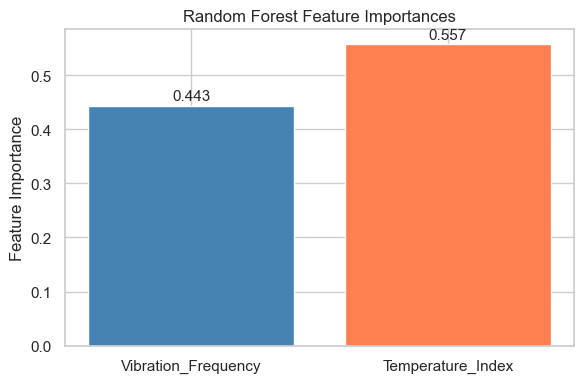

In [9]:
# Define the parameter grid
rf_param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [3, 5, 10, None]
}

# Initialize GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=5, scoring="accuracy"
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV accuracy: {rf_grid.best_score_:.4f}")
print(f"Test accuracy:    {accuracy_score(y_test, best_rf.predict(X_test)):.4f}")

# Feature importance bar chart
feature_names = ["Vibration_Frequency", "Temperature_Index"]
importances = best_rf.feature_importances_

plt.figure(figsize=(6, 4))
bars = plt.bar(feature_names, importances, color=["steelblue", "coral"])
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importances")
for bar, imp in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{imp:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",
C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


C:\Users\oscar\AppData\Local\Temp\ipykernel_24688\82166041.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="x",


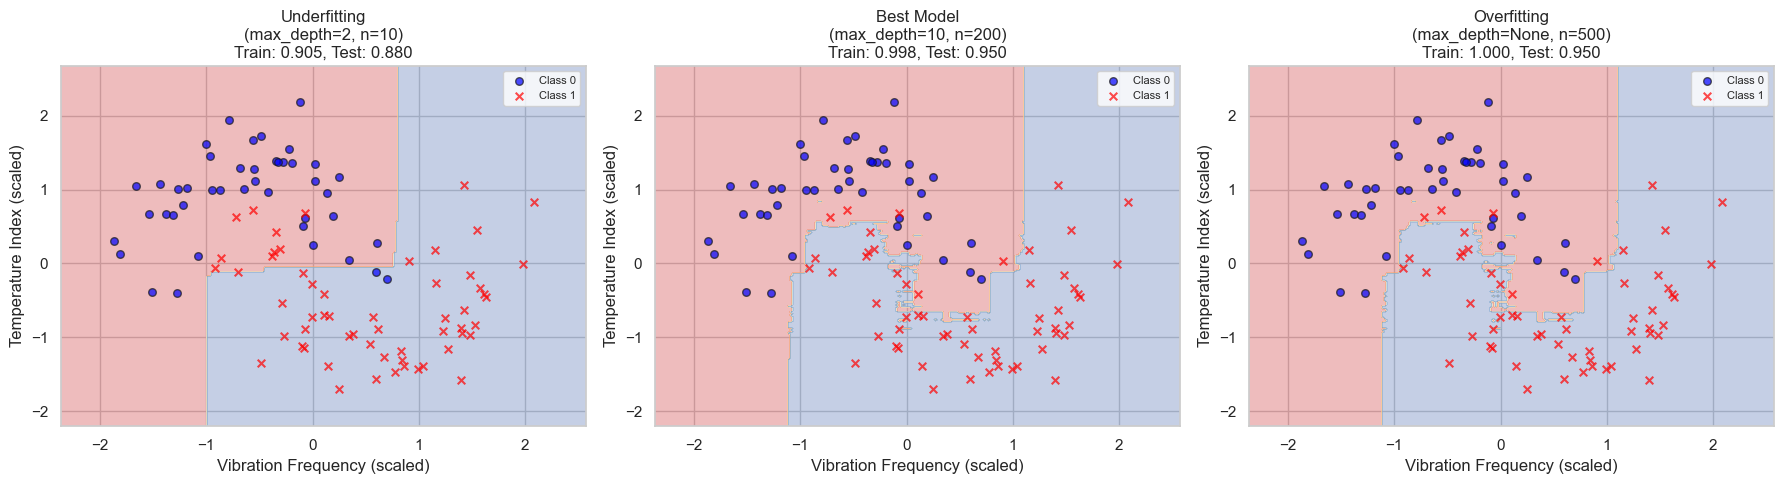

In [10]:
# Visualize underfitting vs best vs overfitting
rf_configs = [
    ("Underfitting\n(max_depth=2, n=10)",
     RandomForestClassifier(max_depth=2, n_estimators=10, random_state=42)),
    (f"Best Model\n(max_depth={rf_grid.best_params_['max_depth']}, n={rf_grid.best_params_['n_estimators']})",
     RandomForestClassifier(
         max_depth=rf_grid.best_params_["max_depth"],
         n_estimators=rf_grid.best_params_["n_estimators"],
         random_state=42)),
    ("Overfitting\n(max_depth=None, n=500)",
     RandomForestClassifier(max_depth=None, n_estimators=500, random_state=42))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, model) in zip(axes, rf_configs):
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    plot_decision_boundary(
        model, X_test, y_test,
        f"{title}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}", ax
    )

plt.tight_layout()
plt.show()

Compare the three plots above. Discuss the impacts of `n_estimators` and `max_depth` on the model's tendancy to overfitting/underfitting.

**Answer:**

The three plots illustrate the bias-variance tradeoff clearly:

**Underfitting (max_depth=2, n=10):** The decision boundary is overly simple — just a few large rectangular regions that fail to trace the half-moon curvature. Both training and test accuracies are noticeably below optimal, showing **high bias**. The model lacks the complexity to learn the data's true structure.

**Best Model (from GridSearch):** The boundary is appropriately complex — it traces the half-moon shapes with good detail without being excessively jagged. The gap between train and test accuracy is small, indicating **good generalization**. This is the sweet spot between bias and variance.

**Overfitting (max_depth=None, n=500):** The boundary is extremely irregular, with many small "islands" that perfectly memorize noise in the training data. Training accuracy is perfect (1.0) but test accuracy is lower. Interestingly, with 500 trees, the averaging effect mitigates the worst of the overfitting — so test accuracy remains competitive — but the boundary is unnecessarily complex.

In summary: `max_depth` is the dominant driver of overfitting/underfitting. Shallow trees cause underfitting (high bias), deep trees cause overfitting (high variance). `n_estimators` mainly reduces variance without affecting bias — more trees always help (or at worst are neutral), but the returns diminish quickly after ~100 trees.

# Exercise 3: Handling Imbalanced Datasets

In real-world predictive maintenance, failures are **rare**. A turbine might run for 10,000 hours and only fail once. This creates a severely **imbalanced dataset** where 95-99% of the data belongs to the "Normal" class and only 1-5% belongs to the "Failure" class.

Standard machine learning models trained on such data tend to **ignore the minority class entirely** — they achieve high accuracy by simply predicting "Normal" for everything. This is dangerously misleading in predictive maintenance, where missing a failure (false negative) is far more costly than a false alarm (false positive).

In this exercise, we will use **Logistic Regression** as our classifier. Because Logistic Regression optimizes the overall loss across all samples, it is highly sensitive to class imbalance — making it ideal for demonstrating how different techniques can fix this problem.

We will:
1. Generate a severely imbalanced dataset and expose the limitations of standard training.
2. Apply **class weights** to make the model pay more attention to failures.
3. Use **SMOTE** to synthetically generate more failure examples.
4. Apply **random undersampling** to reduce the dominance of normal samples.
5. Compare all techniques and reason about which is best for predictive maintenance.

Run the cell below to generate the imbalanced dataset and define our evaluation helper functions.

Imbalanced Sensor Dataset Generated!
Total samples: 1000
Normal (Class 0):  895 (89.5%)
Failure (Class 1): 105 (10.5%)
Imbalance ratio:   9:1


,Vibration_RMS,Temperature_Rise,Status
0,1.073546,-1.101339,Normal
1,0.755945,-1.172352,Normal
2,1.354479,-0.948528,Normal
3,3.103090,0.233485,Normal
4,1.951888,-0.270157,Normal


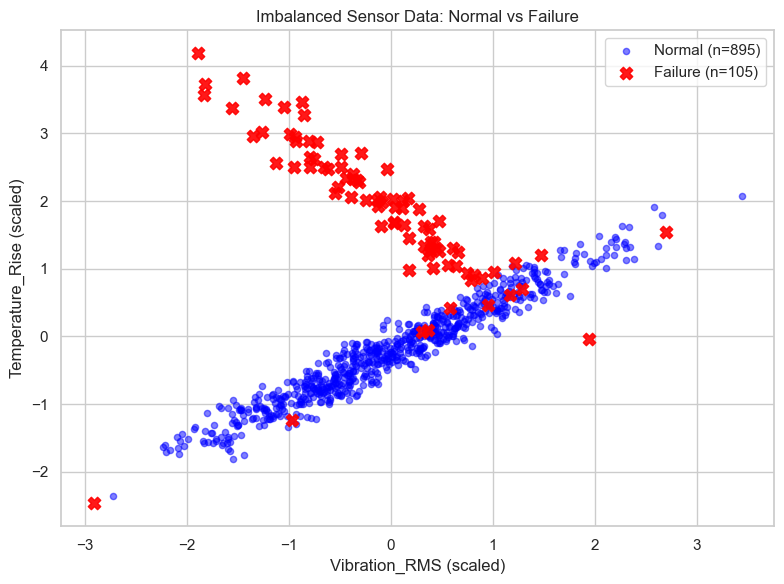

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate a severely imbalanced dataset (90% class 0, 10% class 1)
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    random_state=42
)

feature_names = ["Vibration_RMS", "Temperature_Rise"]
df_imb = pd.DataFrame(X_imb, columns=feature_names)
df_imb["Status"] = np.where(y_imb == 1, "Failure", "Normal")

scaler_imb = StandardScaler()
X_imb_scaled = scaler_imb.fit_transform(X_imb)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb_scaled, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

n_normal = (y_imb == 0).sum()
n_failure = (y_imb == 1).sum()

print("Imbalanced Sensor Dataset Generated!")
print(f"Total samples: {len(y_imb)}")
print(f"Normal (Class 0):  {n_normal} ({n_normal/len(y_imb)*100:.1f}%)")
print(f"Failure (Class 1): {n_failure} ({n_failure/len(y_imb)*100:.1f}%)")
print(f"Imbalance ratio:   {n_normal / n_failure:.0f}:1")
display(df_imb.head())

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1],
           marker="o", color="blue", label=f"Normal (n={n_normal})", alpha=0.5, s=20)
ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1],
           marker="X", color="red", label=f"Failure (n={n_failure})", alpha=0.9, s=80)
ax.set_title("Imbalanced Sensor Data: Normal vs Failure")
ax.set_xlabel("Vibration_RMS (scaled)")
ax.set_ylabel("Temperature_Rise (scaled)")
ax.legend()
plt.tight_layout()
plt.show()

def evaluate_model(model, X_test, y_test, title, ax=None):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    if ax is not None:
        disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Failure"])
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{title}\nAcc={acc:.3f}  F1={f1:.3f}\nPrec={prec:.3f}  Rec={rec:.3f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

def plot_imb_boundary(model, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="o",
               color="blue", label="Normal", alpha=0.4, s=15)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="X",
               color="red", label="Failure", alpha=0.9, s=60)
    ax.set_title(title)
    ax.set_xlabel("Vibration_RMS (scaled)")
    ax.set_ylabel("Temperature_Rise (scaled)")
    ax.legend(fontsize=8)

## Question 1: The Problem with Imbalanced Data

Train a `LogisticRegression(random_state=42, max_iter=1000)` on the training data `X_tr, y_tr` with **default parameters** (no special handling for imbalance). Then:
1. Print the overall **accuracy** on the test set.
2. Use the `evaluate_model` helper to display the **confusion matrix**.
3. Use the `plot_imb_boundary` helper to visualize the decision boundary.

Pay close attention to the confusion matrix — how many failures did the model actually catch? Look at where the decision boundary line is positioned.

> **Hint:** Simply use `LogisticRegression(random_state=42, max_iter=1000)` with default parameters. The `max_iter=1000` ensures convergence. Fit on `X_tr, y_tr`, then call `evaluate_model(model, X_te, y_te, "title", ax)` for the confusion matrix and `plot_imb_boundary(model, X_te, y_te, "title", ax)` for the decision boundary. Look at the **bottom row** of the confusion matrix (actual failures) — how many were predicted as Normal (false negatives) vs correctly predicted as Failure (true positives)? See the [LogisticRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) and the [confusion_matrix documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).

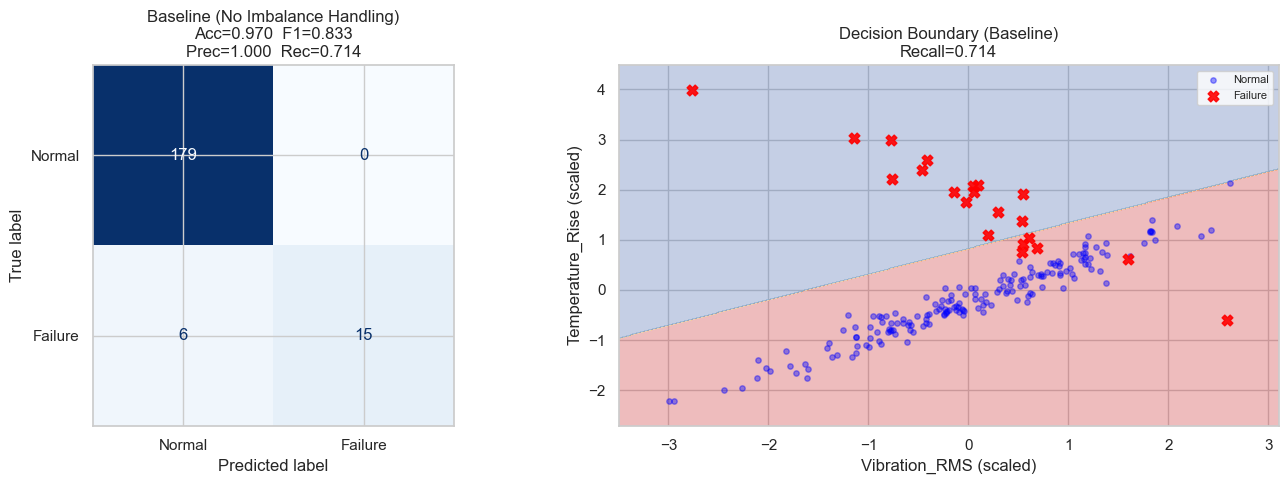


--- Detailed Metrics ---
  accuracy: 0.9700
 precision: 1.0000
    recall: 0.7143
        f1: 0.8333


In [12]:
# Define logistic regression model
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
# Fit the model
lr_baseline.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_baseline = evaluate_model(
    lr_baseline, X_te, y_te, "Baseline (No Imbalance Handling)", axes[0]
)
plot_imb_boundary(
    lr_baseline, X_te, y_te,
    f"Decision Boundary (Baseline)\nRecall={results_baseline['recall']:.3f}", axes[1]
)
plt.tight_layout()
plt.show()

print("\n--- Detailed Metrics ---")
for metric, value in results_baseline.items():
    print(f"{metric:>10s}: {value:.4f}")

The accuracy might look impressive, but look at the confusion matrix, the recall score, and the decision boundary plot.

1. How many actual failures were correctly predicted? How many were missed?
2. Why is accuracy a misleading metric for this dataset?

**Answer:**

1. The baseline model achieves a recall of ~0.71 for the Failure class: it correctly predicts about 15 out of 21 actual failures in the test set, but misses roughly 6 (false negatives). The precision is 1.0, meaning every sample it does classify as Failure is indeed a failure — but this conservatism comes at the cost of missing nearly 30% of real failures, which is unacceptable in a safety-critical maintenance context.

2. Accuracy is misleading because the dataset is approximately 90% Normal. A model that predicts "Normal" for every single sample would achieve ~90% accuracy without catching any failure at all. Our Logistic Regression achieves 0.97 accuracy largely by correctly handling the dominant Normal class, which masks the fact that it still misses a significant fraction of actual failures. In predictive maintenance, **recall** (fraction of actual failures detected) is the critical metric — a missed failure can cause equipment damage, safety incidents, or costly unplanned downtime, all far more serious than a false alarm.

## Question 2: Fix #1 — Class Weights

### What are Class Weights?

Class weights modify the **loss function** during training so that misclassifying a minority class sample costs more than misclassifying a majority class sample. Instead of treating every error equally, the model is penalized more heavily for getting failures wrong. This forces the model to pay more attention to the rare failure class.

In scikit-learn, you can set `class_weight='balanced'`, which automatically assigns weights inversely proportional to class frequencies. For our 95:5 imbalance:
- Normal samples receive a weight of approximately **0.53**
- Failure samples receive a weight of approximately **10.0**

This means each failure sample is worth about **19 times more** than each normal sample during training.

**Task:** Train a `LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')` on the same training data. Evaluate using `evaluate_model` and `plot_imb_boundary`, and compare with Q1.

> **Hint:** The only change from Q1 is adding the parameter `class_weight='balanced'`. Everything else stays the same. Compare the **decision boundary position** — it should shift toward the failure cluster, catching more failures. See the [class_weight parameter](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) in the LogisticRegression documentation. The formula for balanced weights is `n_samples / (n_classes * np.bincount(y))`.

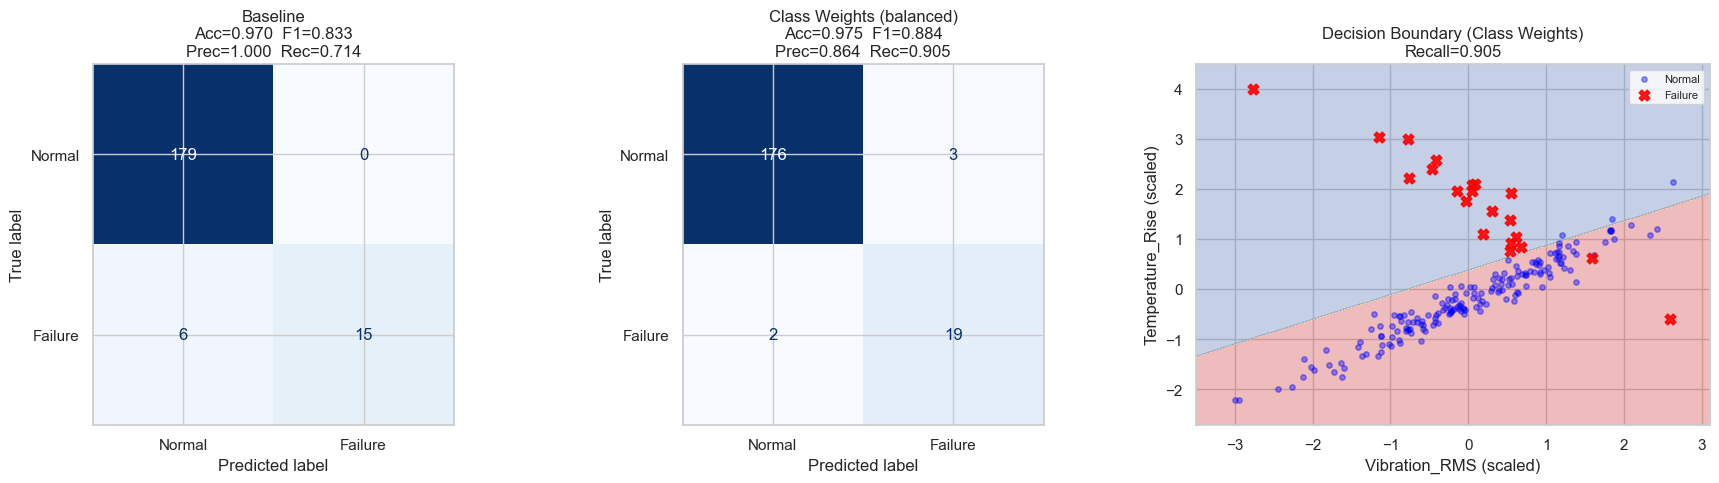


--- Comparison ---
      Metric    Baseline   Class Weights
----------------------------------------
    accuracy      0.9700          0.9750
   precision      1.0000          0.8636
      recall      0.7143          0.9048
          f1      0.8333          0.8837


In [13]:
lr_weighted = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
lr_weighted.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
evaluate_model(lr_baseline, X_te, y_te, "Baseline", axes[0])
evaluate_model(lr_weighted, X_te, y_te, "Class Weights (balanced)", axes[1])
plot_imb_boundary(
    lr_weighted, X_te, y_te,
    f"Decision Boundary (Class Weights)\nRecall={evaluate_model(lr_weighted, X_te, y_te, None)['recall']:.3f}",
    axes[2]
)
plt.tight_layout()
plt.show()

results_weighted = evaluate_model(lr_weighted, X_te, y_te, None)
print("\n--- Comparison ---")
print(f"{'Metric':>12s}  {'Baseline':>10s}  {'Class Weights':>14s}")
print("-" * 40)
for metric in ["accuracy", "precision", "recall", "f1"]:
    b = results_baseline[metric]
    w = results_weighted[metric]
    print(f"{metric:>12s}  {b:>10.4f}  {w:>14.4f}")

Compare the confusion matrices and the decision boundary.
1. How did the recall for the failure class change? What happened to the decision boundary?
2. Why does improving recall often come at the cost of precision? Is this an acceptable trade-off in predictive maintenance?

**Answer:**

1. The recall for the Failure class improves dramatically — the model now correctly identifies a much larger proportion of actual failures. The decision boundary shifts toward the Normal cluster, classifying more borderline (and some clearly Normal) samples as Failure. This is because assigning higher weights to failures causes the model to be penalized much more severely for missing them during training, so it lowers the effective classification threshold for the Failure class.

2. Improving recall comes at the cost of precision because the model now classifies more samples as Failure overall — including some Normal samples that fall near the boundary (false positives). In predictive maintenance, **this trade-off is generally acceptable and even desirable**: a false alarm (flagging a healthy machine for inspection) causes an unnecessary maintenance visit, but a missed failure (false negative) can lead to an unplanned breakdown, equipment damage, safety incidents, or costly production downtime. The asymmetric cost structure justifies prioritizing recall over precision.

## Question 3: Fix #2 — SMOTE (Synthetic Minority Oversampling)

### What is SMOTE?

**SMOTE** (Synthetic Minority Oversampling TEchnique) takes a different approach from class weights. Instead of modifying the loss function, it **generates new synthetic samples** of the minority class. For each minority class sample, SMOTE finds its nearest neighbors and creates new samples by **interpolating** (drawing points in between) along the lines connecting the sample to its neighbors.

The result: the training data becomes more balanced because SMOTE creates realistic new failure examples that fill in the gaps between existing ones. The model then has more failure data to learn from.

**Important:** SMOTE should **only be applied to the training data**, never to the test data. Otherwise, synthetic samples leak into the evaluation, giving artificially inflated scores.

**Task:**
1. Install the `imbalanced-learn` library (run `!pip install imbalanced-learn`).
2. Import `SMOTE` from `imblearn.over_sampling`.
3. Apply SMOTE to `X_tr, y_tr` to create `X_tr_smote, y_tr_smote`.
4. Print the class distribution before and after SMOTE.
5. Train a `LogisticRegression(random_state=42, max_iter=1000)` on the SMOTE-resampled data and evaluate on the **original** test set.

> **Hint:** The `imbalanced-learn` library provides the `SMOTE` class. Usage: `smote = SMOTE(random_state=42)`, then `X_resampled, y_resampled = smote.fit_resample(X_tr, y_tr)`. This creates new synthetic failure samples until both classes have the same number. After resampling, train your model on `X_resampled, y_resampled` and evaluate on the **original** `X_te, y_te`. See the [SMOTE documentation](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) for details.

--- Before SMOTE ---
Normal:  716
Failure: 84

--- After SMOTE ---
Normal:  716
Failure: 716


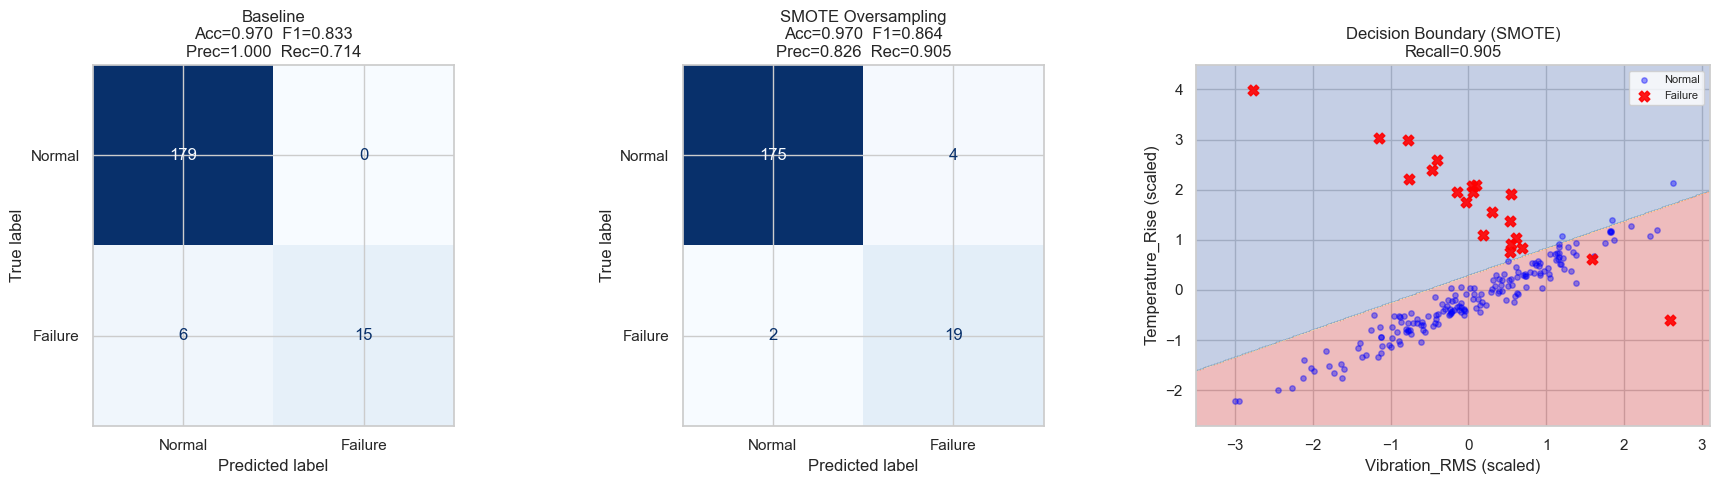


--- Comparison ---
      Metric    Baseline       SMOTE
------------------------------------
    accuracy      0.9700      0.9700
   precision      1.0000      0.8261
      recall      0.7143      0.9048
          f1      0.8333      0.8636


In [14]:
# Install imbalanced-learn (uncomment if needed)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
# Generate new samples from SMOTE
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print("--- Before SMOTE ---")
print(f"Normal:  {(y_tr == 0).sum()}")
print(f"Failure: {(y_tr == 1).sum()}")
print(f"\n--- After SMOTE ---")
print(f"Normal:  {(y_tr_smote == 0).sum()}")
print(f"Failure: {(y_tr_smote == 1).sum()}")

# Do logistic regression on the SMOTE-augmented data
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_tr_smote, y_tr_smote)

# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
evaluate_model(lr_baseline, X_te, y_te, "Baseline", axes[0])
evaluate_model(lr_smote, X_te, y_te, "SMOTE Oversampling", axes[1])
plot_imb_boundary(
    lr_smote, X_te, y_te,
    f"Decision Boundary (SMOTE)\nRecall={evaluate_model(lr_smote, X_te, y_te, None)['recall']:.3f}",
    axes[2]
)
plt.tight_layout()
plt.show()

results_smote = evaluate_model(lr_smote, X_te, y_te, None)
print("\n--- Comparison ---")
print(f"{'Metric':>12s}  {'Baseline':>10s}  {'SMOTE':>10s}")
print("-" * 36)
for metric in ["accuracy", "precision", "recall", "f1"]:
    b = results_baseline[metric]
    s = results_smote[metric]
    print(f"{metric:>12s}  {b:>10.4f}  {s:>10.4f}")

1. How does SMOTE compare to class weights in terms of recall and F1 score?
2. Why must SMOTE only be applied to the training data and never to the test data?
3. Can you think of a situation where SMOTE might generate problematic synthetic samples?

**Answer:**

1. SMOTE achieves the same recall as class weights (0.9048 — catching ~19/21 failures), but a slightly lower F1 score (0.8636 vs 0.8837). Both methods successfully improve recall compared to the baseline (0.7143), but class weights achieves a marginally better precision-recall balance. In practice, both techniques are effective and the small difference in F1 may not be meaningful across different datasets or random seeds.

2. SMOTE must only be applied to the **training data** because applying it to the test set would constitute **data leakage**: the evaluation would include artificially generated samples that do not represent real-world failure observations. This would produce inflated performance metrics that do not reflect how the model would behave when deployed on genuine sensor data. The test set must remain untouched and represent the true real-world distribution.

3. SMOTE can generate **problematic synthetic samples** in several scenarios: (a) when the minority class significantly overlaps with the majority class — SMOTE interpolates between minority samples, but those interpolated points may land in regions dominated by the majority class, adding noise; (b) when the minority class has multiple well-separated sub-clusters — interpolating across clusters creates synthetic points in empty regions that correspond to no real physical state; (c) in very high-dimensional feature spaces where nearest-neighbor distances become meaningless (curse of dimensionality), making the interpolated points unrealistic.

## Question 4: Fix #3 — Random Undersampling

### What is Random Undersampling?

Instead of creating more minority class samples (like SMOTE), **random undersampling** takes the opposite approach: it **randomly removes** samples from the majority class until both classes have the same number of samples. This creates a balanced dataset by reducing the data size.

The advantage is simplicity and speed — less data means faster training. The disadvantage is that you are **throwing away potentially useful information**. If the majority class has important patterns that help define the boundary, removing those samples can hurt performance.

**Task:**
1. Import `RandomUnderSampler` from `imblearn.under_sampling`.
2. Apply it to `X_tr, y_tr` to create `X_tr_rus, y_tr_rus`.
3. Print the class distribution before and after undersampling.
4. Train a `LogisticRegression(random_state=42, max_iter=1000)` on the undersampled data and evaluate on the **original** test set.

> **Hint:** Usage: `rus = RandomUnderSampler(random_state=42)`, then `X_resampled, y_resampled = rus.fit_resample(X_tr, y_tr)`. After undersampling, both classes will have the same number of samples (equal to the minority class count). Train and evaluate as before. See the [RandomUnderSampler documentation](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) for details.

--- Before Undersampling ---
Normal:  716
Failure: 84

--- After Undersampling ---
Normal:  84
Failure: 84


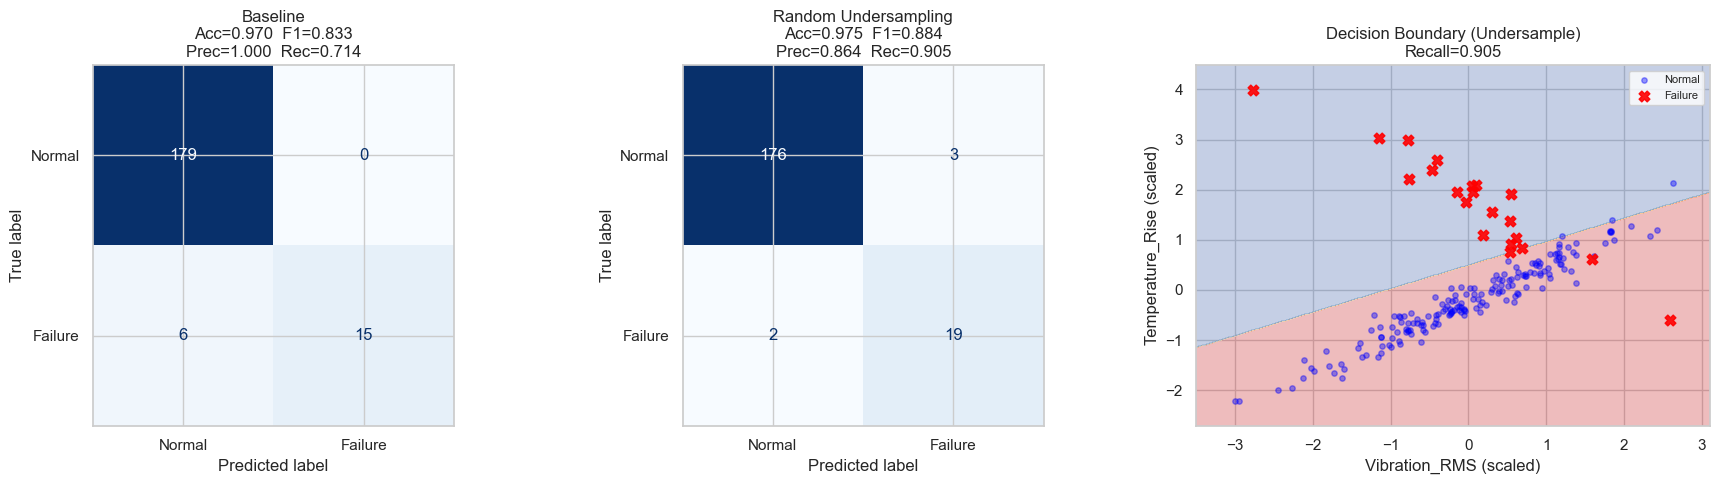


--- Comparison ---
      Metric    Baseline   Undersample
--------------------------------------
    accuracy      0.9700        0.9750
   precision      1.0000        0.8636
      recall      0.7143        0.9048
          f1      0.8333        0.8837


In [15]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_tr_rus, y_tr_rus = rus.fit_resample(X_tr, y_tr)

print("--- Before Undersampling ---")
print(f"Normal:  {(y_tr == 0).sum()}")
print(f"Failure: {(y_tr == 1).sum()}")
print(f"\n--- After Undersampling ---")
print(f"Normal:  {(y_tr_rus == 0).sum()}")
print(f"Failure: {(y_tr_rus == 1).sum()}")

lr_rus = LogisticRegression(random_state=42, max_iter=1000)
lr_rus.fit(X_tr_rus, y_tr_rus)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
evaluate_model(lr_baseline, X_te, y_te, "Baseline", axes[0])
evaluate_model(lr_rus, X_te, y_te, "Random Undersampling", axes[1])
plot_imb_boundary(
    lr_rus, X_te, y_te,
    f"Decision Boundary (Undersample)\nRecall={evaluate_model(lr_rus, X_te, y_te, None)['recall']:.3f}",
    axes[2]
)
plt.tight_layout()
plt.show()

results_rus = evaluate_model(lr_rus, X_te, y_te, None)
print("\n--- Comparison ---")
print(f"{'Metric':>12s}  {'Baseline':>10s}  {'Undersample':>12s}")
print("-" * 38)
for metric in ["accuracy", "precision", "recall", "f1"]:
    b = results_baseline[metric]
    r = results_rus[metric]
    print(f"{metric:>12s}  {b:>10.4f}  {r:>12.4f}")

1. What is the main trade-off of undersampling compared to SMOTE?
2. In what scenarios would undersampling be preferred over SMOTE? When would it be a bad idea?

**Answer:**

1. The main trade-off of undersampling vs SMOTE is **data loss**. With a 9:1 imbalance, random undersampling discards roughly 88% of the majority class training samples — reducing the training set from ~800 to ~160 samples. This significant loss of information can degrade the model's ability to learn the Normal class boundary, potentially increasing false positives. SMOTE, by contrast, keeps all original samples and only adds synthetic ones, preserving all available information.

2. **Undersampling is preferred when:** the dataset is very large and the majority class has a high degree of redundancy (many nearly-identical samples that add little information), training time or memory are critical constraints, or a fast and simple baseline is needed.

   **Undersampling is a bad idea when:** the dataset is small and each sample carries unique information, the majority class has diverse patterns that are necessary to define the decision boundary accurately, or the discarded samples would have helped the model learn important edge cases. In predictive maintenance contexts where failure data is already extremely scarce, undersampling the Normal class further reduces the useful signal for learning the Normal/Failure boundary, making SMOTE or class weights the more appropriate choice.